In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import MACCSkeys
from tdc.single_pred import ADME
import umap

In [3]:
data = ADME(name = 'BBB_Martins')
split = data.get_split()
split.keys()

Downloading...
100%|██████████| 138k/138k [00:00<00:00, 8.60MiB/s]
Loading...
Done!


dict_keys(['train', 'valid', 'test'])

In [4]:
train_data = split["train"]
val_data = split["valid"]
test_data = split["test"]

In [5]:
train_data.head()
val_data.head()
test_data.head()

,Drug_ID,Drug,Y
0,mevastatin,CC[C@H](C)C(=O)O[C@H]1CCC=C2C=C[C@H](C)[C@H](C...,1
1,anseculin,COc1cc2oc(=O)c(C)c(C)c2cc1OCCCN1CCN(c2ccccc2OC...,1
2,moxalactam,CO[C@@]1(NC(=O)C(C(=O)O)c2ccc(O)cc2)C(=O)N2C(C...,0
3,taclamine,c1ccc2c(c1)CCc1cccc3c1C2CN1CCCCC31,1
4,indriline,CN(C)CCC1(c2ccccc2)C=Cc2ccccc21,1


In [6]:
try_smiles = train_data['Drug'][0]

In [7]:
mol_obj = Chem.MolFromSmiles(try_smiles)
np.array(AllChem.GetMorganFingerprintAsBitVect(mol_obj,radius = 4, nBits = 512))
np.array(AllChem.GetMACCSKeysFingerprint(mol_obj))

[16:12:01] DEPRECATION WARNING: please use MorganGenerator


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0])

In [8]:
def create_dataset_morgan(data):
    fp_lst = []
    smiles_lst = list(data['Drug'])
    y_data = list(data['Y'])
    y_data_clean = []
    for smiles, y_value in zip(smiles_lst, y_data):
        mol = Chem.MolFromSmiles(smiles)
        if mol != None:
            fp_lst.append(np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius = 4, nBits=512)))
            y_data_clean.append(y_value)
        else:
            continue
    return fp_lst, y_data_clean

In [9]:
def create_dataset_maccs(data):
    fp_lst = []
    smiles_lst = list(data['Drug'])
    y_data = list(data['Y'])
    y_data_clean =[]
    for smiles, y_value in zip(smiles_lst,y_data):
        if Chem.MolFromSmiles(smiles) != None:
            fp_lst.append(np.array(AllChem.GetMACCSKeysFingerprint(Chem.MolFromSmiles(smiles))))
            y_data_clean.append(y_value)
        else:
            continue        
    return fp_lst, y_data_clean

In [ ]:
train_data_morgan, train_y_morgan = create_dataset_morgan (train_data)
val_data_morgan, val_y_morgan = create_dataset_morgan (val_data)
test_data_morgan, test_y_morgan = create_dataset_morgan(test_data)
train_data_maccs, train_y_maccs = create_dataset_maccs (train_data)
val_data_maccs, val_y_maccs = create_dataset_maccs (val_data)
test_data_maccs, test_y_maccs = create_dataset_maccs(test_data)

[16:12:01] DEPRECATION WARNING: please use MorganGenerator
[16:12:01] DEPRECATION WARNING: please use MorganGenerator
[16:12:01] DEPRECATION WARNING: please use MorganGenerator
[16:12:01] DEPRECATION WARNING: please use MorganGenerator
[16:12:01] DEPRECATION WARNING: please use MorganGenerator
[16:12:01] DEPRECATION WARNING: please use MorganGenerator
[16:12:01] DEPRECATION WARNING: please use MorganGenerator
[16:12:01] DEPRECATION WARNING: please use MorganGenerator
[16:12:01] DEPRECATION WARNING: please use MorganGenerator
[16:12:01] DEPRECATION WARNING: please use MorganGenerator
[16:12:01] DEPRECATION WARNING: please use MorganGenerator
[16:12:01] DEPRECATION WARNING: please use MorganGenerator
[16:12:01] DEPRECATION WARNING: please use MorganGenerator
[16:12:01] DEPRECATION WARNING: please use MorganGenerator
[16:12:01] DEPRECATION WARNING: please use MorganGenerator
[16:12:01] DEPRECATION WARNING: please use MorganGenerator
[16:12:01] DEPRECATION WARNING: please use MorganGenerat

In [12]:
from sklearn.preprocessing import normalize
from sklearn.preprocessing import StandardScaler
X_morgan = np.array(train_data_morgan)   
y_morgan = np.array(train_y_morgan)

X_maccs  = np.array(train_data_maccs)    
y_maccs  = np.array(train_y_maccs)

scaler_morgan = StandardScaler()
X_morgan_std = scaler_morgan.fit_transform(X_morgan)

scaler_maccs = StandardScaler()
X_maccs_std = scaler_maccs.fit_transform(X_maccs)

In [13]:
from sklearn.decomposition import PCA
pca_morgan = PCA(n_components=2)
X_morgan_2d = pca_morgan.fit_transform(X_morgan_std)

pca_maccs = PCA(n_components=2)
X_maccs_2d = pca_maccs.fit_transform(X_maccs_std)

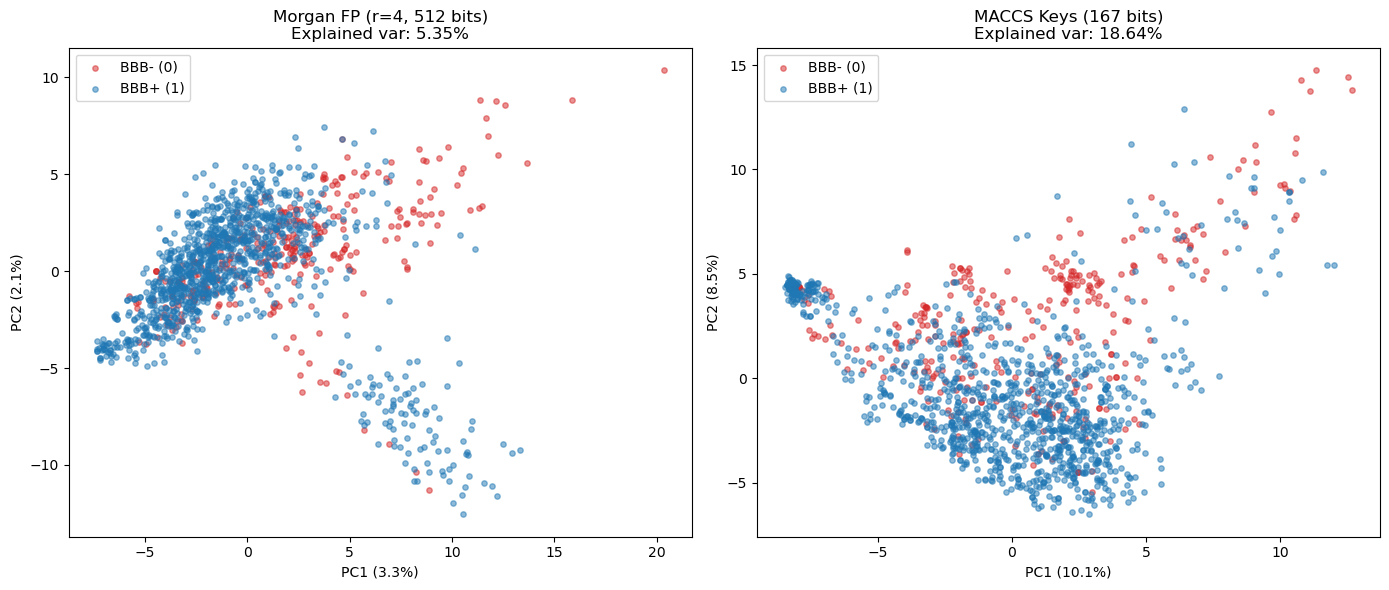

In [17]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for label, color, name in [(0, 'tab:red', 'BBB- (0)'),
                           (1, 'tab:blue', 'BBB+ (1)')]:
    mask = y_morgan == label
    axes[0].scatter(X_morgan_2d[mask, 0], X_morgan_2d[mask, 1],
                    c=color, label=name, alpha=0.5, s=15)
axes[0].set_title(f'Morgan FP (r=4, 512 bits)\n'
                  f'Explained var: {pca_morgan.explained_variance_ratio_.sum():.2%}')
axes[0].set_xlabel(f'PC1 ({pca_morgan.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca_morgan.explained_variance_ratio_[1]:.1%})')
axes[0].legend()

for label, color, name in [(0, 'tab:red', 'BBB- (0)'),
                           (1, 'tab:blue', 'BBB+ (1)')]:
    mask = y_maccs == label
    axes[1].scatter(X_maccs_2d[mask, 0], X_maccs_2d[mask, 1],
                    c=color, label=name, alpha=0.5, s=15)
axes[1].set_title(f'MACCS Keys (167 bits)\n'
                  f'Explained var: {pca_maccs.explained_variance_ratio_.sum():.2%}')
axes[1].set_xlabel(f'PC1 ({pca_maccs.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca_maccs.explained_variance_ratio_[1]:.1%})')
axes[1].legend()

plt.tight_layout()
plt.show()

In [21]:
reducer_morgan = umap.UMAP(
    n_components=2,
    metric='jaccard',
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)
X_morgan_2d = reducer_morgan.fit_transform(X_morgan)

reducer_maccs = umap.UMAP(
    n_components=2,
    metric='jaccard',
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)
X_maccs_2d = reducer_maccs.fit_transform(X_maccs)

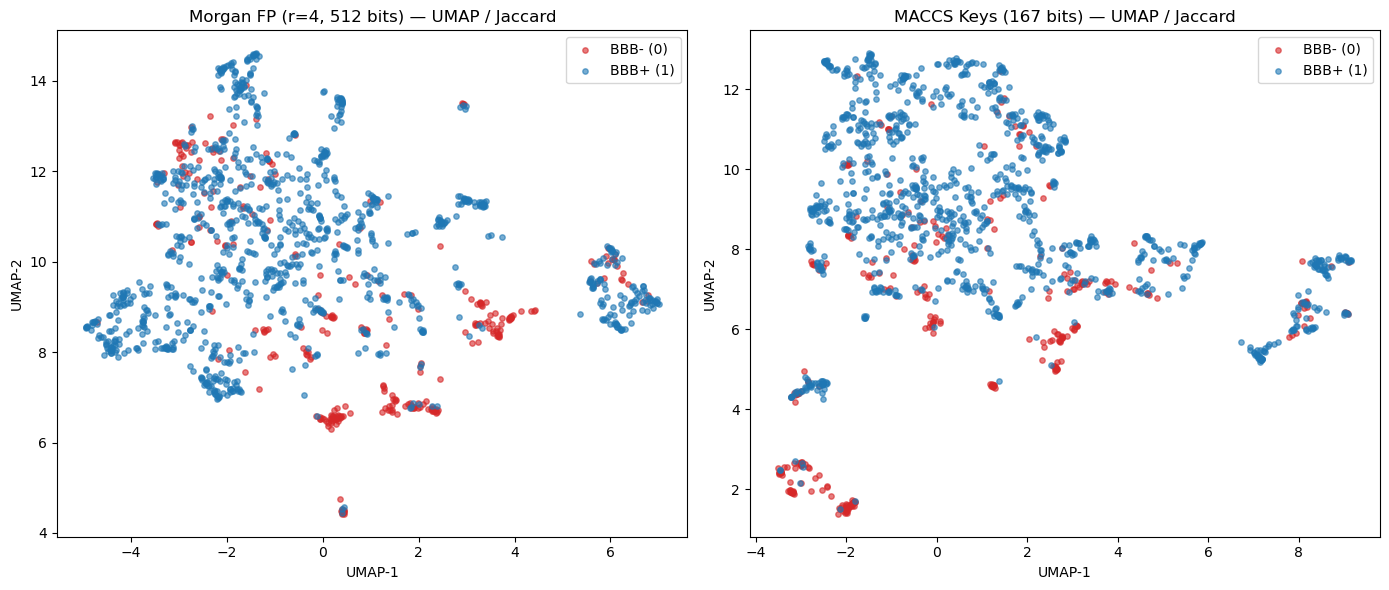

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for label, color, name in [(0, 'tab:red', 'BBB- (0)'),
                           (1, 'tab:blue', 'BBB+ (1)')]:
    mask = y_morgan == label
    axes[0].scatter(X_morgan_2d[mask, 0], X_morgan_2d[mask, 1],
                    c=color, label=name, alpha=0.6, s=15)
axes[0].set_title('Morgan FP (r=4, 512 bits) — UMAP / Jaccard')
axes[0].set_xlabel('UMAP-1')
axes[0].set_ylabel('UMAP-2')
axes[0].legend()

for label, color, name in [(0, 'tab:red', 'BBB- (0)'),
                           (1, 'tab:blue', 'BBB+ (1)')]:
    mask = y_maccs == label
    axes[1].scatter(X_maccs_2d[mask, 0], X_maccs_2d[mask, 1],
                    c=color, label=name, alpha=0.6, s=15)
axes[1].set_title('MACCS Keys (167 bits) — UMAP / Jaccard')
axes[1].set_xlabel('UMAP-1')
axes[1].set_ylabel('UMAP-2')
axes[1].legend()

plt.tight_layout()
plt.show()